# Condition Monitoring of a Hydraulic System

This project focuses on **predicting the health condition of a hydraulic test rig** using sensor data collected during cyclic load operations. The dataset was originally published by ZeMA gGmbH and contains readings from 17 sensors — including pressure, temperature, vibration, motor power, volume flow, and virtual cooling metrics — sampled at different frequencies (1 Hz, 10 Hz, and 100 Hz).

**Goal:** Build a classification model that can predict the **cooler condition** (close to total failure, reduced efficiency, or full efficiency) based on the sensor readings.

We'll walk through the following steps:
1. Loading and exploring the dataset
2. Visualizing class distributions and feature relationships
3. Preparing the data (scaling, encoding)
4. Training an SGD classifier
5. Evaluating the model and making predictions

## Step 1: Import Libraries

We start by bringing in the essential Python libraries:
- **NumPy & Pandas** — for numerical operations and data handling
- **Seaborn & Matplotlib** — for creating visualizations
- **Scikit-learn** — for preprocessing, splitting data, and building the classifier

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import tensorflow as tf
from tensorflow.keras import layers

## Step 2: Load the Dataset

The dataset (`Final.csv`) contains sensor readings from a hydraulic test rig. Each row represents one 60-second load cycle, and the columns hold aggregated values from 17 different sensors along with target condition labels for the cooler, valve, pump, and accumulator.

In [2]:
# Read the processed CSV file into a DataFrame
df = pd.read_csv("Final.csv")

# Quick look at the first 5 rows to understand the structure
df.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
0,160.673492,109.466914,1.991475,0.0,9.842170,9.728098,35.621983,40.978767,38.471017,31.745250,...,2538.929167,0.576950,39.601350,1.862750,59.157183,3.0,100.0,0.0,130.0,1.0
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,36.676967,41.532767,38.978967,34.493867,...,2531.498900,0.565850,25.786433,1.255550,59.335617,3.0,100.0,0.0,130.0,1.0
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,37.880800,42.442450,39.631950,35.646150,...,2519.928000,0.576533,22.218233,1.113217,59.543150,3.0,100.0,0.0,130.0,1.0
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337430,38.879050,43.403983,40.403383,36.579467,...,2511.541633,0.569267,20.459817,1.062150,59.794900,3.0,100.0,0.0,130.0,1.0
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,39.803917,44.332750,41.310550,37.427900,...,2503.449500,0.577367,19.787017,1.070467,59.455267,3.0,100.0,0.0,130.0,1.0


## Step 3: Explore the Data

Let's take a closer look at what columns are available, get summary statistics, and check data types. This helps us understand the scale of each feature and whether there's any missing data.

In [3]:
# List all column names in the dataset
columns = df.columns
columns

Index(['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'TS1', 'TS2', 'TS3', 'TS4',
       'FS1', 'FS2', 'EPS1', 'VS1', 'CE', 'CP', 'SE', 'Cooler_Condition',
       'Valve_Condition', 'Internal_Pump_Leakage', 'Hydraulic_Accumulator',
       'Stable_Flag'],
      dtype='object')

In [4]:
# We only want the sensor/feature columns — drop the target labels so we have a clean feature list
columns = columns.drop(['Cooler_Condition', 'Internal_Pump_Leakage', 'Valve_Condition', 'Hydraulic_Accumulator', 'Stable_Flag'])

In [5]:
# Summary statistics — gives us the mean, std, min/max for each numeric column
df.describe()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,160.485315,109.379906,1.753227,2.600266,9.163320,9.079363,45.424567,50.365979,47.662121,40.735654,...,2495.509203,0.613315,31.299077,1.808399,55.287900,41.240816,90.693878,0.669388,107.199546,0.342857
std,4.699425,4.986585,0.251902,4.279355,0.576296,0.549589,7.991933,7.396254,7.451888,8.107878,...,73.836682,0.060260,11.575330,0.278263,8.960189,42.383143,10.681802,0.817233,16.435848,0.474772
min,155.391547,104.406307,0.840252,0.000000,8.365801,8.321527,35.313783,40.859400,38.245733,30.390800,...,2361.747267,0.524367,17.555983,1.062150,18.276617,3.000000,73.000000,0.000000,90.000000,0.000000
25%,158.100195,106.962382,1.729733,0.000000,8.547239,8.487167,36.237150,41.864183,39.123183,31.272567,...,2442.933467,0.555100,20.084650,1.550100,56.270183,3.000000,80.000000,0.000000,90.000000,0.000000
50%,158.960895,107.730169,1.779630,0.000000,9.115781,9.031516,44.836650,49.780583,47.070250,40.429050,...,2480.926633,0.610183,27.392533,1.739683,58.758150,20.000000,100.000000,0.000000,100.000000,0.000000
75%,161.000735,109.421612,1.932047,3.503266,9.844351,9.729276,54.104317,58.584467,55.694433,49.409500,...,2548.211467,0.649850,46.677383,2.148483,59.656900,100.000000,100.000000,1.000000,130.000000,1.000000
max,180.922708,131.589089,2.023398,10.207068,9.978511,9.856591,57.899283,61.958467,59.423167,53.060417,...,2740.641000,0.839067,47.903667,2.840100,60.755300,100.000000,100.000000,2.000000,130.000000,1.000000


In [6]:
# Check data types and non-null counts — good to confirm there are no missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PS1                    2205 non-null   float64
 1   PS2                    2205 non-null   float64
 2   PS3                    2205 non-null   float64
 3   PS4                    2205 non-null   float64
 4   PS5                    2205 non-null   float64
 5   PS6                    2205 non-null   float64
 6   TS1                    2205 non-null   float64
 7   TS2                    2205 non-null   float64
 8   TS3                    2205 non-null   float64
 9   TS4                    2205 non-null   float64
 10  FS1                    2205 non-null   float64
 11  FS2                    2205 non-null   float64
 12  EPS1                   2205 non-null   float64
 13  VS1                    2205 non-null   float64
 14  CE                     2205 non-null   float64
 15  CP  

## Step 4: Visualize Target Variable Distributions

Before modeling, it's helpful to see how the target labels are distributed. If one class heavily dominates, we might face class imbalance issues. We'll also look at how the Stable Flag relates to each condition.

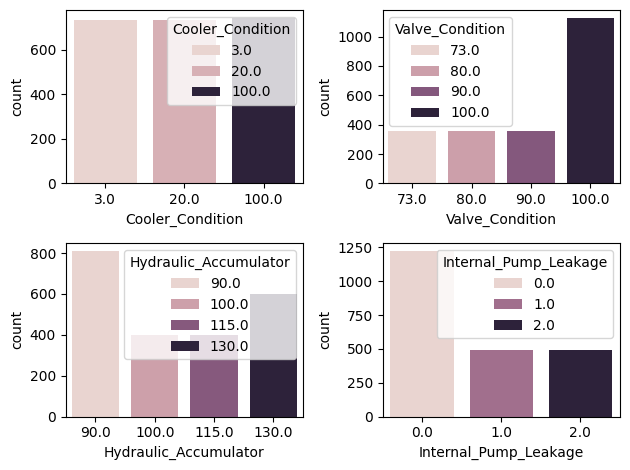

In [7]:
# Count plots for each target variable — shows how many samples fall into each condition category
plt.subplot(2, 2, 1)
sns.countplot(x='Cooler_Condition', data=df, hue='Cooler_Condition')
plt.subplot(2, 2, 2)
sns.countplot(x='Valve_Condition', data=df, hue='Valve_Condition')
plt.subplot(2, 2, 3)
sns.countplot(x='Hydraulic_Accumulator', data=df, hue='Hydraulic_Accumulator')
plt.subplot(2, 2, 4)
sns.countplot(x='Internal_Pump_Leakage', data=df, hue='Internal_Pump_Leakage')

plt.tight_layout()

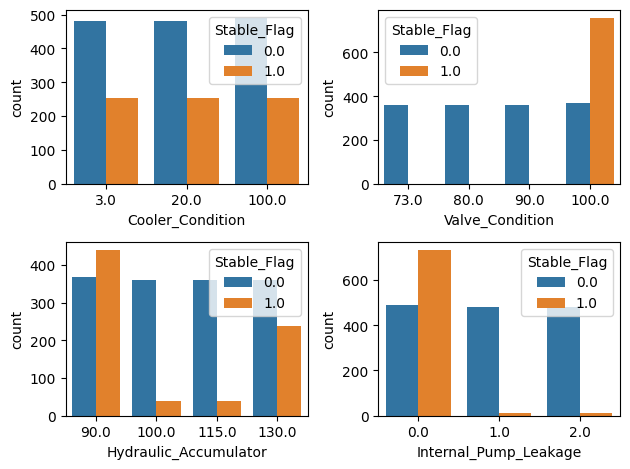

In [8]:
# Same conditions, but now colored by Stable_Flag to see if unstable cycles skew any class
plt.subplot(2, 2, 1)
sns.countplot(x='Cooler_Condition', data=df, hue='Stable_Flag')
plt.subplot(2, 2, 2)
sns.countplot(x='Valve_Condition', data=df, hue='Stable_Flag')
plt.subplot(2, 2, 3)
sns.countplot(x='Hydraulic_Accumulator', data=df, hue='Stable_Flag')
plt.subplot(2, 2, 4)
sns.countplot(x='Internal_Pump_Leakage', data=df, hue='Stable_Flag')

plt.tight_layout()

### Strip Plots: Feature vs Stable Flag

Strip plots give us a sense of how each sensor reading varies for stable vs. unstable cycles. If a feature shows clear separation between the two groups, it's likely a useful predictor.

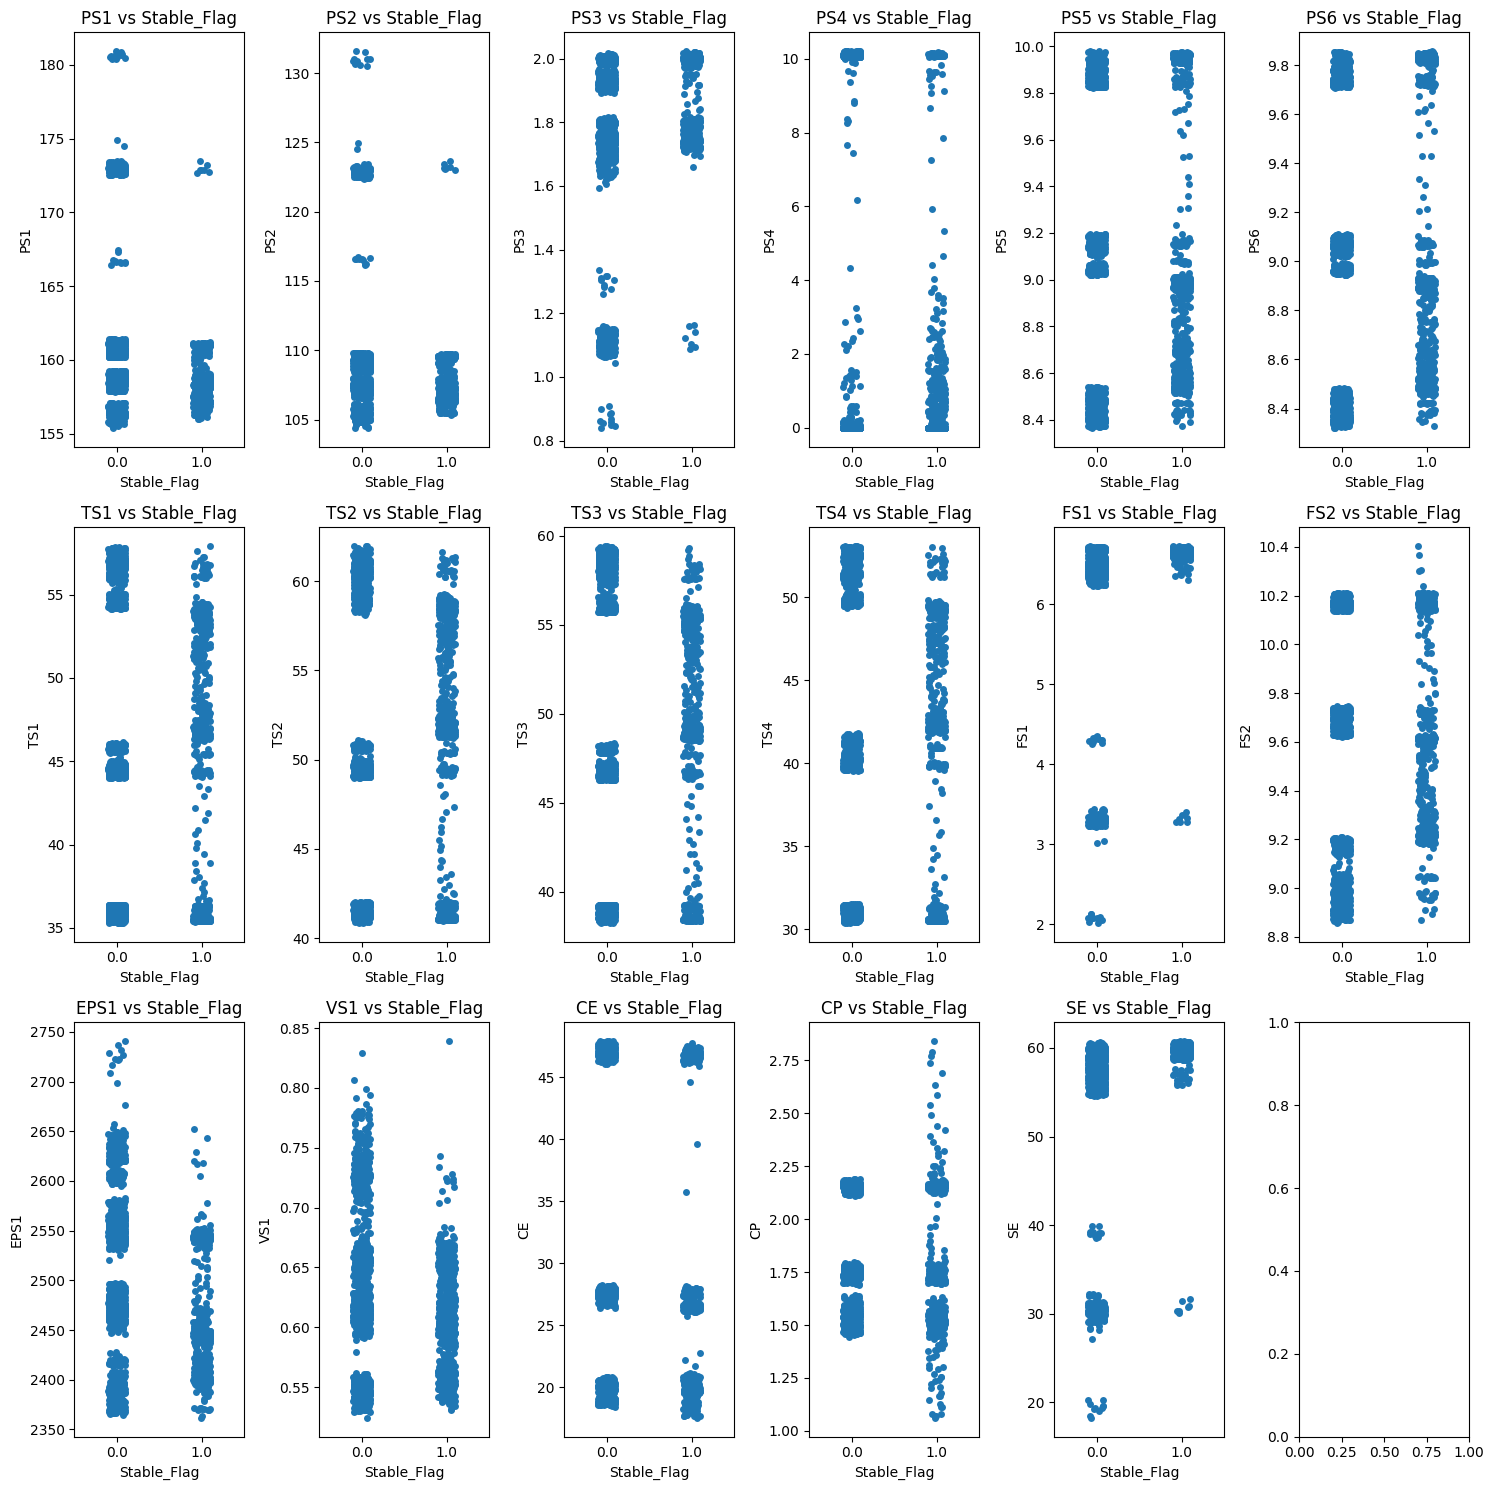

In [9]:
# Create a grid of strip plots — one for each sensor feature vs the Stable_Flag
rows = 6
cols = 3
fig, ax = plt.subplots(cols, rows, figsize=(15, 15))
ax = ax.flatten()

for i, col_name in enumerate(columns):
    sns.stripplot(x='Stable_Flag', y=col_name, data=df, ax=ax[i])
    ax[i].set_title(f'{col_name} vs Stable_Flag')

plt.tight_layout()

### Correlation Heatmap

A correlation matrix helps us identify relationships between features. Highly correlated features might carry redundant information, and strong correlations with targets point to useful predictors.

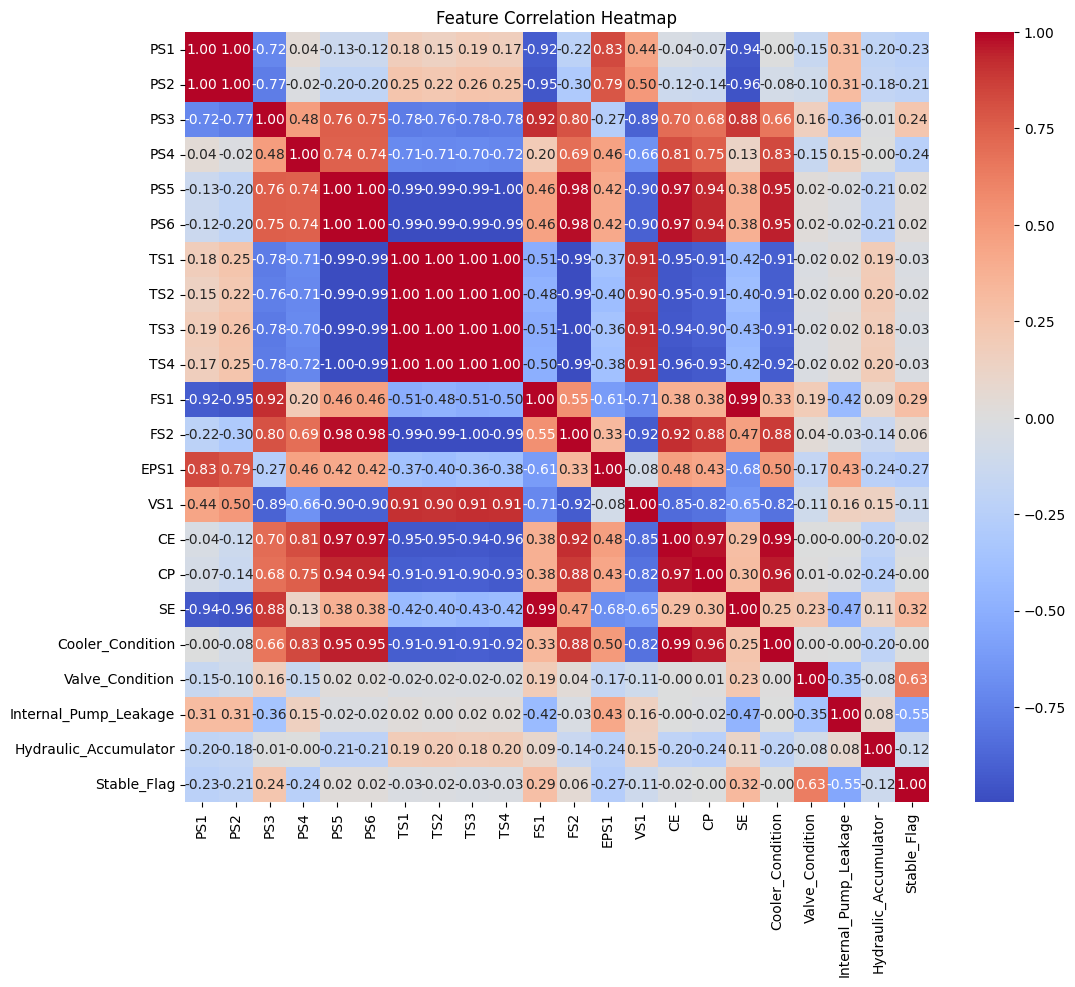

In [10]:
# Compute the pairwise correlation between all numeric columns
corr = df.corr()

# Plot it as a heatmap with annotations for easy reading
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
# Quick sanity check — look at the last few rows before we start modifying the DataFrame
df.tail()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
2200,161.227572,109.779581,2.001438,10.202473,9.972037,9.850361,35.313783,40.874800,38.269267,30.404733,...,2543.911033,0.550833,46.628517,2.160600,59.03310,100.0,100.0,0.0,90.0,0.0
2201,161.206070,109.787481,1.998781,10.197919,9.966184,9.844854,35.321600,40.868883,38.268250,30.416233,...,2543.411333,0.547483,46.689817,2.151450,59.06800,100.0,100.0,0.0,90.0,0.0
2202,161.192120,109.756174,1.993436,10.196824,9.964329,9.842629,35.319183,40.875950,38.246367,30.426250,...,2542.729767,0.545233,46.472300,2.143300,59.13235,100.0,100.0,0.0,90.0,0.0
2203,161.208917,109.793884,2.007077,10.198588,9.968232,9.846690,35.324767,40.876067,38.245733,30.414283,...,2544.046333,0.537017,46.544967,2.148483,58.97080,100.0,100.0,0.0,90.0,0.0
2204,161.217128,109.792176,2.002690,10.203126,9.973638,9.851949,35.322233,40.859400,38.248917,30.390800,...,2543.818300,0.546583,46.647933,2.157050,59.05390,100.0,100.0,0.0,90.0,0.0


## Transition to Step 5: Data Preparation Strategy

### Why Data Preprocessing Matters

Before training any machine learning model, raw sensor data must be prepared through a series of transformations:

1. **Normalization/Scaling**: Sensor readings span different ranges
   - Pressure sensors: 0 - 350 bar
   - Temperature sensors: 0 - 60°C  
   - Vibration: 0 - 9.9 units
   
   Machine learning algorithms (especially neural networks and distance-based methods like K-NN) perform poorly without scaling, as features with larger numerical ranges can dominate the learning process.

2. **Encoding Categorical Targets**: Our target variables are categorical labels (e.g., "Full Efficiency", "Reduced Efficiency", "Close to Total Failure")
   - Models require numeric representations
   - Ordinal encoding converts categories to integers (0, 1, 2, ...) preserving any ordinal relationship
   - Example: Cooler condition 0=Full Efficiency → 1=Reduced Efficiency → 2=Close to Total Failure

### Data Flow Diagram

```
Raw DataFrame (Final.csv)
        ↓
[Stable_Flag removed] → Cleaner feature set
        ↓
[StandardScaler applied to sensor features] → Normalized features
        ↓
[OrdinalEncoder applied to targets] → Numeric condition codes
        ↓
Model-Ready Dataset (X, y pairs)
```

#### Remove Non-Predictive Features
- **Stable_Flag** is removed after EDA because:
  - It's an indicator variable (not a feature from system sensors)
  - System stability is already captured in sensor behavior
  - Removing it prevents information leakage (models should learn instability patterns from sensor data, not explicit flags)

In [12]:
df.drop('Stable_Flag', axis=1, inplace=True)

#### Feature Scaling with StandardScaler
The StandardScaler applies **Z-score normalization**:
$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

Where:
- $x$ = original feature value
- $\mu$ = mean of the feature across all samples
- $\sigma$ = standard deviation

**Result**: Each feature has mean ≈ 0 and standard deviation ≈ 1, creating a standardized feature space.

**Benefits**:
- Gradient descent converges faster during neural network training
- Prevents numerical instability from extreme ranges
- Enables fair feature importance comparison
- Required for many scikit-learn algorithms (SVM, KNN, Ridge/Lasso)

In [13]:
scaler = StandardScaler()
df_columns = df.columns
df_columns = df_columns.drop(['Cooler_Condition', 'Internal_Pump_Leakage', 'Valve_Condition', 'Hydraulic_Accumulator'])
df[df_columns] = scaler.fit_transform(df[df_columns])
df.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator
0,0.040052,0.017452,0.946011,-0.607768,1.178219,1.180667,-1.226838,-1.269472,-1.233673,-1.109099,...,1.458639,0.588187,-0.603614,0.717401,0.195369,0.431929,3.0,100.0,0.0,130.0
1,0.025116,-0.005018,0.885494,-0.607768,0.818900,0.819207,-1.094802,-1.194553,-1.165493,-0.770017,...,1.677960,0.487534,-0.787858,-0.476349,-1.987238,0.451847,3.0,100.0,0.0,130.0
2,-0.029286,-0.044341,0.869570,-0.607768,0.637365,0.634410,-0.944137,-1.071532,-1.077847,-0.627866,...,1.595919,0.330789,-0.610530,-0.784678,-2.498861,0.475014,3.0,100.0,0.0,130.0
3,-0.063262,-0.063204,0.767727,-0.607768,0.478173,0.469669,-0.819201,-0.941500,-0.974301,-0.512727,...,1.454379,0.217183,-0.731146,-0.936623,-2.682422,0.503117,3.0,100.0,0.0,130.0
4,-0.103194,-0.089956,0.672953,-0.607768,0.339211,0.329909,-0.703450,-0.815899,-0.852537,-0.408060,...,1.309819,0.107563,-0.596698,-0.994760,-2.652528,0.465204,3.0,100.0,0.0,130.0


#### Target Variable Encoding
Ordinal encoding transforms categorical condition labels to numeric codes:
- Cooler_Condition: ["Full Efficiency", "Reduced Efficiency", "Close to Total Failure"] → [0, 1, 2]
- Similarly for Valve_Condition, Pump_Leakage, and Accumulator conditions

This numeric representation allows the model to compute loss functions and gradients during training.

In [14]:
encoder = OrdinalEncoder()
df[['Cooler_Condition', 'Valve_Condition', 'Internal_Pump_Leakage', "Hydraulic_Accumulator"]] = encoder.fit_transform(df[['Cooler_Condition', 'Valve_Condition', 'Internal_Pump_Leakage', "Hydraulic_Accumulator"]])
df.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator
0,0.040052,0.017452,0.946011,-0.607768,1.178219,1.180667,-1.226838,-1.269472,-1.233673,-1.109099,...,1.458639,0.588187,-0.603614,0.717401,0.195369,0.431929,0.0,3.0,0.0,3.0
1,0.025116,-0.005018,0.885494,-0.607768,0.818900,0.819207,-1.094802,-1.194553,-1.165493,-0.770017,...,1.677960,0.487534,-0.787858,-0.476349,-1.987238,0.451847,0.0,3.0,0.0,3.0
2,-0.029286,-0.044341,0.869570,-0.607768,0.637365,0.634410,-0.944137,-1.071532,-1.077847,-0.627866,...,1.595919,0.330789,-0.610530,-0.784678,-2.498861,0.475014,0.0,3.0,0.0,3.0
3,-0.063262,-0.063204,0.767727,-0.607768,0.478173,0.469669,-0.819201,-0.941500,-0.974301,-0.512727,...,1.454379,0.217183,-0.731146,-0.936623,-2.682422,0.503117,0.0,3.0,0.0,3.0
4,-0.103194,-0.089956,0.672953,-0.607768,0.339211,0.329909,-0.703450,-0.815899,-0.852537,-0.408060,...,1.309819,0.107563,-0.596698,-0.994760,-2.652528,0.465204,0.0,3.0,0.0,3.0


In [15]:
print(df['Cooler_Condition'].value_counts())
print(df['Valve_Condition'].value_counts())
print(df['Internal_Pump_Leakage'].value_counts())
print(df['Hydraulic_Accumulator'].value_counts())

Cooler_Condition
2.0    741
0.0    732
1.0    732
Name: count, dtype: int64
Valve_Condition
3.0    1125
0.0     360
1.0     360
2.0     360
Name: count, dtype: int64
Internal_Pump_Leakage
0.0    1221
2.0     492
1.0     492
Name: count, dtype: int64
Hydraulic_Accumulator
0.0    808
3.0    599
2.0    399
1.0    399
Name: count, dtype: int64


- **17 feature columns** will remain (17 sensors), all scaled to mean=0, std=1
- **4 target columns** will contain integer codes (0, 1, 2, 3[for some targets]) representing condition states
- **Dataset shape**: (2205 samples, 21 total columns)
- Ready for train-test split and model training

In [16]:
df.shape

(2205, 21)

Preparing X and y to feed into model

In [17]:
X = df.drop([
    'Cooler_Condition',
    'Valve_Condition',
    'Internal_Pump_Leakage',
    'Hydraulic_Accumulator'
], axis=1)

y_cooler = df['Cooler_Condition']
y_valve = df['Valve_Condition']
y_pump = df['Internal_Pump_Leakage']
y_acc = df['Hydraulic_Accumulator']

Splitting data into 80% training set and 20% testing set

In [18]:
X_train, X_test, y_cooler_train, y_cooler_test, \
y_valve_train, y_valve_test, \
y_pump_train, y_pump_test, \
y_acc_train, y_acc_test = train_test_split(
    X,
    y_cooler,
    y_valve,
    y_pump,
    y_acc,
    test_size=0.2,
    random_state=42
)

In [19]:
X_train.shape, y_cooler_train.shape, y_valve_train.shape, y_pump_train.shape, y_acc_train.shape

((1764, 17), (1764,), (1764,), (1764,), (1764,))

#### Flow chart of tensorflow layers
![Alt text for screen readers](layer_diagram.png)

In [20]:
inputs = tf.keras.Input(shape=(X.shape[1],))

x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)

cooler_output = layers.Dense(3, activation='softmax', name='cooler')(x)
valve_output = layers.Dense(4, activation='softmax', name='valve')(x)
pump_output = layers.Dense(3, activation='softmax', name='pump')(x)
acc_output = layers.Dense(4, activation='softmax', name='accumulator')(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=[cooler_output, valve_output, pump_output, acc_output]
)

model.compile(
    optimizer='adam',
    loss={
        'cooler': 'sparse_categorical_crossentropy',
        'valve': 'sparse_categorical_crossentropy',
        'pump': 'sparse_categorical_crossentropy',
        'accumulator': 'sparse_categorical_crossentropy'
    },
    metrics=['accuracy','accuracy','accuracy','accuracy']
)

In [21]:
model.fit(
    X_train,
    {
        'cooler': y_cooler_train,
        'valve': y_valve_train,
        'pump': y_pump_train,
        'accumulator': y_acc_train
    },
    epochs=200,
)

Epoch 1/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accumulator_accuracy: 0.3968 - accumulator_loss: 1.3165 - cooler_accuracy: 0.8396 - cooler_loss: 0.6225 - loss: 4.1637 - pump_accuracy: 0.5488 - pump_loss: 0.9590 - valve_accuracy: 0.4994 - valve_loss: 1.2570
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accumulator_accuracy: 0.4291 - accumulator_loss: 1.2472 - cooler_accuracy: 0.9938 - cooler_loss: 0.1757 - loss: 3.3546 - pump_accuracy: 0.5913 - pump_loss: 0.7835 - valve_accuracy: 0.5153 - valve_loss: 1.1420
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accumulator_accuracy: 0.4756 - accumulator_loss: 1.1432 - cooler_accuracy: 0.9977 - cooler_loss: 0.0522 - loss: 2.8916 - pump_accuracy: 0.6990 - pump_loss: 0.6096 - valve_accuracy: 0.5062 - valve_loss: 1.0814
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accumulator_accuracy: 0.4739 - accumulator_loss: 1.1043 - cooler_accuracy: 0.9983 - cooler_loss: 0.0307 - loss: 2.6883 - pump_accuracy: 0.8095 - pump_loss: 0.474

In [22]:
model.evaluate(X_test, {
        'cooler': y_cooler_test,
        'valve': y_valve_test,
        'pump': y_pump_test,
        'accumulator': y_acc_test
    })

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accumulator_accuracy: 0.9161 - accumulator_loss: 0.3758 - cooler_accuracy: 0.9977 - cooler_loss: 0.0104 - loss: 0.5293 - pump_accuracy: 0.9977 - pump_loss: 0.0094 - valve_accuracy: 0.9569 - valve_loss: 0.1317          


[0.5293485522270203,
 0.010400532744824886,
 0.1316799819469452,
 0.009419878013432026,
 0.37576156854629517,
 0.9160997867584229,
 0.997732400894165,
 0.997732400894165,
 0.956916093826294]

In [44]:
rows, col = X_test.shape

In [45]:
import random

In [46]:
data = random.randint(0, rows-1)
single_data = X_test.iloc[data:data+1]
single_data

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE
1575,0.116132,0.042357,0.941939,0.211061,1.333139,1.333204,-1.23709,-1.238058,-1.232167,-1.244928,0.472225,1.153484,0.620286,-0.88662,1.316512,1.220053,0.41052


In [47]:
pre = model.predict(single_data)
pre

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


[array([[3.7313793e-08, 1.8759478e-19, 1.0000000e+00]], dtype=float32),
 array([[9.3729200e-32, 3.1396668e-13, 1.1244267e-04, 9.9988759e-01]],
       dtype=float32),
 array([[1.0000000e+00, 3.7288217e-25, 0.0000000e+00]], dtype=float32),
 array([[9.9999428e-01, 6.1277126e-09, 5.8628284e-09, 5.6919544e-06]],
       dtype=float32)]

In [48]:
y_test = pd.concat([y_cooler_test, y_valve_test,y_pump_test,y_acc_test], axis=1)
y_test

,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator
1966,2.0,2.0,2.0,1.0
1091,1.0,1.0,2.0,2.0
1468,2.0,3.0,0.0,0.0
438,0.0,1.0,0.0,2.0
1790,2.0,3.0,0.0,3.0
...,...,...,...,...
1314,1.0,2.0,0.0,1.0
930,1.0,3.0,0.0,0.0
1735,2.0,1.0,1.0,3.0
59,0.0,3.0,0.0,3.0


In [49]:
pred = model.predict(single_data)

targets = ['Cooler_Condition', 'Valve_Condition', 'Internal_Pump_Leakage', 'Hydraulic_Accumulator']

for i, col in enumerate(targets):
    pred_class = np.argmax(pred[i], axis=1)[0]
    print(col)
    print(f"Predicted class: {pred_class}")
    print(f"Actual class: {y_test.iloc[data][col]}")
    print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Cooler_Condition
Predicted class: 2
Actual class: 2.0
------------------------------
Valve_Condition
Predicted class: 3
Actual class: 3.0
------------------------------
Internal_Pump_Leakage
Predicted class: 0
Actual class: 0.0
------------------------------
Hydraulic_Accumulator
Predicted class: 0
Actual class: 0.0
------------------------------


Saving model to use later

In [50]:
model.save("predictive_maintenance_model.keras")

In [51]:
from tensorflow.keras.models import load_model

In [52]:
loaded_model = load_model("predictive_maintenance_model.keras")
loaded_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      2,304 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        528 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cooler (Dense)      │ (None, 3)         │         51 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ valve (Dense)       │ (None, 4)         │         68 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pump (Dense)        │ (None, 3)         │         51 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ accumulator (Dense) │ (None, 4)         │         68 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,220 (157.11 KB)

 Trainable params: 13,406 (52.37 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,814 (104.75 KB)

Saving scaler function to scale incoming values from dashboard to predict values

In [54]:
import joblib

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']